**Slow Tetris**

Enter max pieces (or press Enter for infinite): 32


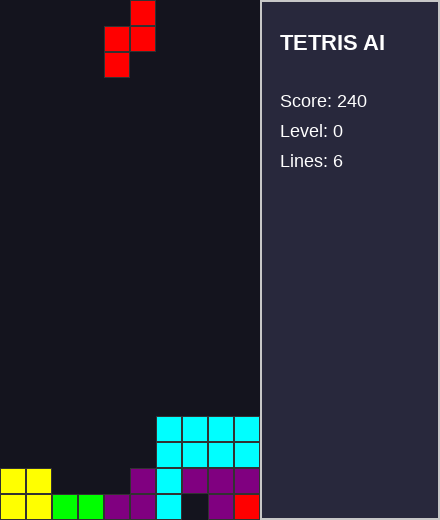

In [ ]:
# Tetris AI - polished GUI with score, level, fall speed, and user piece cap
!pip -q install pygame pillow

import pygame, random, time, copy
from IPython.display import display, Image

# --- Config ---
ROWS, COLS = 20, 10
CELL = 26
BOARD_W, BOARD_H = COLS * CELL, ROWS * CELL
PANEL_W = 180
WIDTH, HEIGHT = BOARD_W + PANEL_W, BOARD_H
BASE_DROP_INTERVAL = 0.4   # base seconds per downward step (level 0)

# Heuristic weights
W_LINES, W_HOLES, W_BUMP, W_HEIGHT = 0.76, -0.36, -0.18, -0.51

# Colors
C_BG    = (20,20,30)
C_PANEL = (40,40,60)
C_BORDER= (200,200,200)
C_TEXT  = (255,255,255)
C_SHAPES=[(0,255,255),(255,255,0),(128,0,128),(0,255,0),
          (255,0,0),(0,0,255),(255,165,0)]

# Shapes
SHAPES = [
    [[1,1,1,1]], [[1,1],[1,1]], [[0,1,0],[1,1,1]],
    [[0,1,1],[1,1,0]], [[1,1,0],[0,1,1]],
    [[1,0,0],[1,1,1]], [[0,0,1],[1,1,1]]
]

def rotate_shape(shape): return [list(r)[::-1] for r in zip(*shape)]
def all_rotations(shape):
    rots,cur=[],shape
    for _ in range(4):
        if cur not in rots: rots.append(cur)
        cur=rotate_shape(cur)
    return rots
ROTATIONS=[all_rotations(s) for s in SHAPES]

# --- Board helpers ---
def empty_board(): return [[0]*COLS for _ in range(ROWS)]
def copy_board(b): return [r[:] for r in b]
def collision(board,shape,x,y):
    for r,row in enumerate(shape):
        for c,v in enumerate(row):
            if v:
                nx,ny=x+c,y+r
                if nx<0 or nx>=COLS or ny>=ROWS: return True
                if ny>=0 and board[ny][nx]: return True
    return False
def merge(board,shape,x,y,idx):
    for r,row in enumerate(shape):
        for c,v in enumerate(row):
            if v and y+r>=0: board[y+r][x+c]=idx+1
def clear_lines(board):
    new=[r for r in board if any(c==0 for c in r)]
    cleared=ROWS-len(new)
    while len(new)<ROWS: new.insert(0,[0]*COLS)
    return new,cleared

# --- Board analysis for AI ---
def col_heights(board):
    h=[0]*COLS
    for x in range(COLS):
        for y in range(ROWS):
            if board[y][x]: h[x]=ROWS-y; break
    return h
def holes(board):
    h=0
    for x in range(COLS):
        seen=False
        for y in range(ROWS):
            if board[y][x]: seen=True
            elif seen: h+=1
    return h
def bumpiness_height(board):
    h=col_heights(board)
    return sum(abs(h[i]-h[i+1]) for i in range(COLS-1)),sum(h)
def evaluate(board,lines):
    return (W_LINES*lines)+(W_HOLES*holes(board))+(W_BUMP*bumpiness_height(board)[0])+(W_HEIGHT*bumpiness_height(board)[1])
def hard_drop_y(board,shape,x,y):
    while not collision(board,shape,x,y+1): y+=1
    return y
def best_move(board,idx):
    best=None
    for r,shp in enumerate(ROTATIONS[idx]):
        for x in range(-2,COLS):
            if collision(board,shp,x,0): continue
            y=hard_drop_y(board,shp,x,-2)
            tmp=copy_board(board); merge(tmp,shp,x,y,idx)
            tmp,lines=clear_lines(tmp)
            score=evaluate(tmp,lines)
            if best is None or score>best[-1]: best=(r,x,y,score)
    return best

# --- Rendering ---
pygame.init()
surface=pygame.Surface((WIDTH,HEIGHT))
pygame.font.init()
font_big = pygame.font.SysFont("Arial",22, bold=True)
font_small = pygame.font.SysFont("Arial",18)
img_handle=None

def draw(board,score,level,lines,shape=None,x=0,y=0,cidx=0):
    surface.fill(C_BG)
    # Board
    for yy in range(ROWS):
        for xx in range(COLS):
            if board[yy][xx]:
                pygame.draw.rect(surface,C_SHAPES[(board[yy][xx]-1)%7],
                                 (xx*CELL,yy*CELL,CELL,CELL))
                pygame.draw.rect(surface,(50,50,50),(xx*CELL,yy*CELL,CELL,CELL),1)
    # Current piece
    if shape:
        for r,row in enumerate(shape):
            for c,v in enumerate(row):
                if v and y+r>=0:
                    pygame.draw.rect(surface,C_SHAPES[cidx],
                                     ((x+c)*CELL,(y+r)*CELL,CELL,CELL))
                    pygame.draw.rect(surface,(50,50,50),
                                     ((x+c)*CELL,(y+r)*CELL,CELL,CELL),1)
    # Side panel
    panel_x = BOARD_W
    pygame.draw.rect(surface,C_PANEL,(panel_x,0,PANEL_W,HEIGHT))
    pygame.draw.rect(surface,C_BORDER,(panel_x,0,PANEL_W,HEIGHT),2)

    title = font_big.render("TETRIS AI",True,C_TEXT)
    surface.blit(title,(panel_x+20,30))
    for i,txt in enumerate([f"Score: {score}", f"Level: {level}", f"Lines: {lines}"]):
        surface.blit(font_small.render(txt,True,C_TEXT),(panel_x+20,90+i*30))

def show():
    global img_handle
    pygame.image.save(surface,"frame.png")
    if img_handle is None: img_handle=display(Image("frame.png"),display_id=True)
    else: img_handle.update(Image("frame.png"))

# --- Game loop ---
def new_piece(): return {"idx":random.randrange(len(SHAPES)),"rot":0,"x":COLS//2-2,"y":-2}

def play_ai(max_pieces=None):
    """
    max_pieces = int → stop after that many pieces
    max_pieces = None → run until top-out
    """
    board=empty_board(); piece=new_piece()
    score=0; lines_total=0; level=0; placed=0
    mv=best_move(board,piece["idx"])
    if not mv: return
    target_rot,target_x,_,_=mv

    while True:
        if max_pieces is not None and placed >= max_pieces:
            break

        if piece["rot"]!=target_rot:
            piece["rot"]=(piece["rot"]+1)%len(ROTATIONS[piece["idx"]])
        elif piece["x"]!=target_x:
            step=1 if piece["x"]<target_x else -1
            if not collision(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"]+step,piece["y"]):
                piece["x"]+=step
        else:
            if not collision(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"]+1):
                piece["y"]+=1
            else:
                merge(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"],piece["idx"])
                board,lines=clear_lines(board)
                if lines==1: score+=40*(level+1)
                elif lines==2: score+=100*(level+1)
                elif lines==3: score+=300*(level+1)
                elif lines==4: score+=1200*(level+1)
                lines_total+=lines
                level=lines_total//10
                placed+=1
                piece=new_piece()
                mv=best_move(board,piece["idx"])
                if not mv or collision(board,ROTATIONS[piece["idx"]][0],piece["x"],piece["y"]): break
                target_rot,target_x,_,_=mv

        draw(board,score,level,lines_total,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"],piece["idx"])
        show()

        speed = max(0.05, BASE_DROP_INTERVAL * (0.85 ** level))
        time.sleep(speed)

    print(f"Game Over — pieces: {placed}, lines: {lines_total}, score: {score}, level: {level}")

# --- Ask user ---
user_in = input("Enter max pieces (or press Enter for infinite): ")
max_cap = int(user_in) if user_in.strip() else None
play_ai(max_cap)


**Fast Tetris**

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
Enter max pieces (or press Enter for infinite): 256


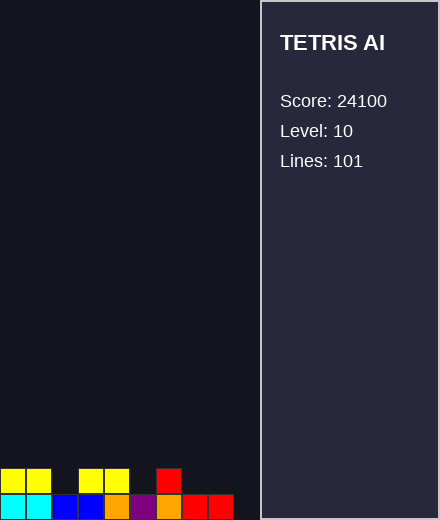

Game Over — pieces: 256, lines: 101, score: 24100, level: 10


In [1]:
# Tetris AI — polished GUI + tuned weights + 7-bag + gentler speed + user piece cap
!pip -q install pygame pillow

import pygame, random, time, copy
from IPython.display import display, Image

# --- Config ---
ROWS, COLS = 20, 10
CELL = 26
BOARD_W, BOARD_H = COLS * CELL, ROWS * CELL
PANEL_W = 180
WIDTH, HEIGHT = BOARD_W + PANEL_W, BOARD_H
BASE_DROP_INTERVAL = 0.4
USE_HARD_DROP = True  # fast version; set False for slow gravity

# --- Tuned AI heuristic weights ---
W_LINES = +1.0
W_HOLES = -0.9
W_BUMP  = -0.3
W_HEIGHT= -0.5

# Colors
C_BG    = (20,20,30)
C_PANEL = (40,40,60)
C_BORDER= (200,200,200)
C_TEXT  = (255,255,255)
C_SHAPES=[(0,255,255),(255,255,0),(128,0,128),
          (0,255,0),(255,0,0),(0,0,255),(255,165,0)]

# Shapes
SHAPES = [
    [[1,1,1,1]], [[1,1],[1,1]], [[0,1,0],[1,1,1]],
    [[0,1,1],[1,1,0]], [[1,1,0],[0,1,1]],
    [[1,0,0],[1,1,1]], [[0,0,1],[1,1,1]]
]

def rotate_shape(shape): return [list(r)[::-1] for r in zip(*shape)]
def all_rotations(shape):
    rots,cur=[],shape
    for _ in range(4):
        if cur not in rots: rots.append(cur)
        cur=rotate_shape(cur)
    return rots
ROTATIONS=[all_rotations(s) for s in SHAPES]

# --- Board helpers ---
def empty_board(): return [[0]*COLS for _ in range(ROWS)]
def copy_board(b): return [r[:] for r in b]
def collision(board,shape,x,y):
    for r,row in enumerate(shape):
        for c,v in enumerate(row):
            if v:
                nx,ny=x+c,y+r
                if nx<0 or nx>=COLS or ny>=ROWS: return True
                if ny>=0 and board[ny][nx]: return True
    return False
def merge(board,shape,x,y,idx):
    for r,row in enumerate(shape):
        for c,v in enumerate(row):
            if v and y+r>=0: board[y+r][x+c]=idx+1
def clear_lines(board):
    new=[r for r in board if any(c==0 for c in r)]
    cleared=ROWS-len(new)
    while len(new)<ROWS: new.insert(0,[0]*COLS)
    return new,cleared

# --- Board analysis for AI ---
def col_heights(board):
    h=[0]*COLS
    for x in range(COLS):
        for y in range(ROWS):
            if board[y][x]: h[x]=ROWS-y; break
    return h
def holes(board):
    h=0
    for x in range(COLS):
        seen=False
        for y in range(ROWS):
            if board[y][x]: seen=True
            elif seen: h+=1
    return h
def bumpiness_height(board):
    h=col_heights(board)
    return sum(abs(h[i]-h[i+1]) for i in range(COLS-1)),sum(h)
def evaluate(board,lines):
    bump,agg_h=bumpiness_height(board)
    return (W_LINES*lines)+(W_HOLES*holes(board))+(W_BUMP*bump)+(W_HEIGHT*agg_h)
def hard_drop_y(board,shape,x,y):
    while not collision(board,shape,x,y+1): y+=1
    return y
def best_move(board,idx):
    best=None
    for r,shp in enumerate(ROTATIONS[idx]):
        for x in range(-2,COLS):
            if collision(board,shp,x,0): continue
            y=hard_drop_y(board,shp,x,-2)
            tmp=copy_board(board); merge(tmp,shp,x,y,idx)
            tmp,lines=clear_lines(tmp)
            score=evaluate(tmp,lines)
            if best is None or score>best[-1]: best=(r,x,y,score)
    return best

# --- 7-bag randomizer ---
bag=[]
def new_piece():
    global bag
    if not bag:
        bag=list(range(len(SHAPES)))
        random.shuffle(bag)
    idx=bag.pop()
    return {"idx":idx,"rot":0,"x":COLS//2-2,"y":-2}

# --- Rendering ---
pygame.init()
surface=pygame.Surface((WIDTH,HEIGHT))
pygame.font.init()
font_big = pygame.font.SysFont("Arial",22, bold=True)
font_small = pygame.font.SysFont("Arial",18)
img_handle=None

def draw(board,score,level,lines,shape=None,x=0,y=0,cidx=0):
    surface.fill(C_BG)
    # Board
    for yy in range(ROWS):
        for xx in range(COLS):
            if board[yy][xx]:
                pygame.draw.rect(surface,C_SHAPES[(board[yy][xx]-1)%7],
                                 (xx*CELL,yy*CELL,CELL,CELL))
                pygame.draw.rect(surface,(50,50,50),(xx*CELL,yy*CELL,CELL,CELL),1)
    # Current piece
    if shape:
        for r,row in enumerate(shape):
            for c,v in enumerate(row):
                if v and y+r>=0:
                    pygame.draw.rect(surface,C_SHAPES[cidx],
                                     ((x+c)*CELL,(y+r)*CELL,CELL,CELL))
                    pygame.draw.rect(surface,(50,50,50),
                                     ((x+c)*CELL,(y+r)*CELL,CELL,CELL),1)
    # Side panel
    panel_x = BOARD_W
    pygame.draw.rect(surface,C_PANEL,(panel_x,0,PANEL_W,HEIGHT))
    pygame.draw.rect(surface,C_BORDER,(panel_x,0,PANEL_W,HEIGHT),2)
    title = font_big.render("TETRIS AI",True,C_TEXT)
    surface.blit(title,(panel_x+20,30))
    for i,txt in enumerate([f"Score: {score}", f"Level: {level}", f"Lines: {lines}"]):
        surface.blit(font_small.render(txt,True,C_TEXT),(panel_x+20,90+i*30))

def show():
    global img_handle
    pygame.image.save(surface,"frame.png")
    if img_handle is None: img_handle=display(Image("frame.png"),display_id=True)
    else: img_handle.update(Image("frame.png"))

# --- Game loop ---
def play_ai(max_pieces=None):
    """
    Run the AI Tetris game.
    max_pieces = int → stop after that many pieces
    max_pieces = None → run until top-out
    """
    board=empty_board(); piece=new_piece()
    score=0; lines_total=0; level=0; placed=0
    mv=best_move(board,piece["idx"])
    if not mv: return
    target_rot,target_x,_,_=mv

    while True:
        if max_pieces is not None and placed >= max_pieces:
            break

        if piece["rot"]!=target_rot:
            piece["rot"]=(piece["rot"]+1)%len(ROTATIONS[piece["idx"]])
        elif piece["x"]!=target_x:
            step=1 if piece["x"]<target_x else -1
            if not collision(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"]+step,piece["y"]):
                piece["x"]+=step
        else:
            if USE_HARD_DROP:
                piece["y"]=hard_drop_y(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"])
                merge(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"],piece["idx"])
                board,lines=clear_lines(board)
                if lines==1: score+=40*(level+1)
                elif lines==2: score+=100*(level+1)
                elif lines==3: score+=300*(level+1)
                elif lines==4: score+=1200*(level+1)
                lines_total+=lines; level=lines_total//10; placed+=1
                piece=new_piece()
                mv=best_move(board,piece["idx"])
                if not mv or collision(board,ROTATIONS[piece["idx"]][0],piece["x"],piece["y"]): break
                target_rot,target_x,_,_=mv
            else:
                if not collision(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"]+1):
                    piece["y"]+=1
                else:
                    merge(board,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"],piece["idx"])
                    board,lines=clear_lines(board)
                    if lines==1: score+=40*(level+1)
                    elif lines==2: score+=100*(level+1)
                    elif lines==3: score+=300*(level+1)
                    elif lines==4: score+=1200*(level+1)
                    lines_total+=lines; level=lines_total//10; placed+=1
                    piece=new_piece()
                    mv=best_move(board,piece["idx"])
                    if not mv or collision(board,ROTATIONS[piece["idx"]][0],piece["x"],piece["y"]): break
                    target_rot,target_x,_,_=mv

        draw(board,score,level,lines_total,ROTATIONS[piece["idx"]][piece["rot"]],piece["x"],piece["y"],piece["idx"])
        show()

        speed=max(0.05, BASE_DROP_INTERVAL*(0.95**level))
        if not USE_HARD_DROP: time.sleep(speed)

    print(f"Game Over — pieces: {placed}, lines: {lines_total}, score: {score}, level: {level}")

# --- Ask user for cap ---
user_in = input("Enter max pieces (or press Enter for infinite): ")
max_cap = int(user_in) if user_in.strip() else None
play_ai(max_cap)
